In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [2]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [3]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [4]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [23]:
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed']=X_train['Age']
print(X_train['Age'].isnull().sum())
print(X_train['Age_imputed'].isnull().sum())

148
148


In [7]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


In [24]:
print(X_train['Age'].isnull().sum())
print(X_train['Age_imputed'].isnull().sum())

148
148


In [33]:
print(X_test['Age_imputed'].isnull().sum())
print(X_test['Age'].dropna().shape[0])

179
150


In [34]:
X_train.loc[
    X_train['Age_imputed'].isnull(),
    'Age_imputed'
] = X_train['Age'].dropna().sample(
    X_train['Age_imputed'].isnull().sum(),
    random_state=42,replace=True
).values

X_test.loc[
    X_test['Age_imputed'].isnull(),
    'Age_imputed'
] = X_test['Age'].dropna().sample(
    X_test['Age_imputed'].isnull().sum(),
    random_state=42,replace=True
).values

In [36]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([27.  ,  7.  , 27.  , 24.  , 54.  ,  4.  , 11.  , 28.  , 33.  ,
       24.  , 37.  , 39.  , 22.  , 25.  , 21.  , 52.  , 29.  , 30.  ,
       30.  , 25.  , 30.5 , 40.  , 51.  , 11.  , 21.  ,  2.  , 43.  ,
       27.  , 31.  , 51.  , 40.  , 24.  , 25.  , 21.  , 39.  ,  2.  ,
       45.  , 35.  , 46.  , 34.  , 41.  , 37.  , 18.  , 19.  , 38.  ,
       34.  , 30.  , 36.  ,  7.  , 16.  , 19.  , 23.5 , 16.  ,  3.  ,
       58.  , 34.  , 36.  , 56.  , 33.  , 35.  , 15.  , 16.  , 29.  ,
       30.  , 44.  , 36.  , 56.  , 33.  ,  0.67, 34.  , 30.  , 24.  ,
       59.  , 20.  , 60.  , 30.  , 21.  , 39.  , 21.  , 44.  ,  0.75,
       18.  , 20.  , 29.  , 62.  , 54.  ,  9.  , 50.  , 45.  , 22.  ,
       24.  , 46.  , 32.  , 14.  , 35.  , 52.  , 18.  , 24.  , 25.  ,
       16.  , 19.  , 29.  , 42.  , 23.  , 27.  , 39.  , 26.  , 36.  ,
       34.  , 23.  , 51.  , 29.  , 19.  , 48.  , 29.  , 21.  , 45.  ,
       21.  , 37.  , 51.  , 27.  , 23.  , 31.  , 33.  , 24.  , 38.  ,
        3.  , 21.  ,

In [37]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,8.0
493,71.0,49.5042,71.0
527,NaN,221.7792,18.0


/tmp/ipykernel_3219/2754436760.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label = 'OG',hist=False)
/tmp/ipykernel_3219/2754436760.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)


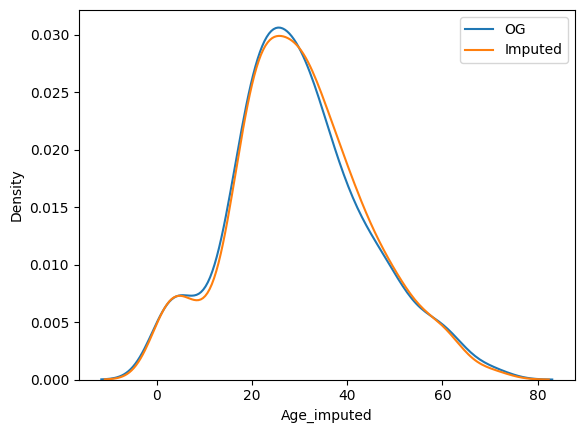

In [49]:
sns.distplot(X_train['Age'],label = 'OG',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)
plt.legend()
plt.show()

<Axes: >

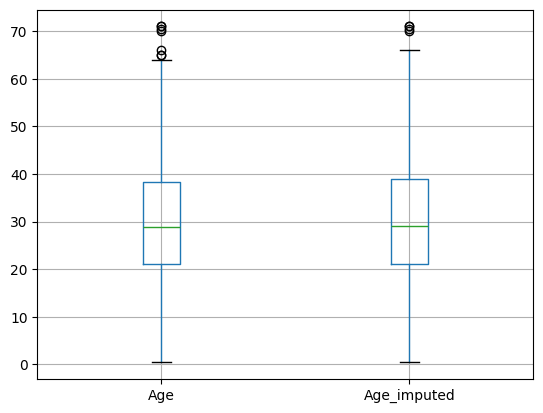

In [50]:
X_train[['Age', 'Age_imputed']].boxplot()

In [51]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,51.846777
Age,71.512440,204.349513,204.349513
Age_imputed,51.846777,204.349513,198.080996


In [52]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  198.08099578375126
